In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import make_scorer, f1_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('wifi_localization.csv', encoding='utf-8-sig' , header=None)
target_col = df.columns[-1] 

print("YÊU CẦU 1: THÔNG SỐ DỮ LIỆU")
print(f"a. Kích thước và chiều dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\nb. Kiểu dữ liệu của các thuộc tính:\n", df.dtypes)
print(f"\nc. Số lượng thực thể của các giá trị nhãn phòng ({target_col}):\n", df[target_col].value_counts())

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col, errors='ignore')
print("\nd. Giá trị lớn nhất, bé nhất và trung bình của các cột số thực:")
display(df[numeric_cols].agg(['min', 'max', 'mean']).T)

YÊU CẦU 1: THÔNG SỐ DỮ LIỆU
a. Kích thước và chiều dữ liệu: 2000 dòng, 8 cột

b. Kiểu dữ liệu của các thuộc tính:
 0    int64
1    int64
2    int64
3    int64
4    int64
5    int64
6    int64
7    int64
dtype: object

c. Số lượng thực thể của các giá trị nhãn phòng (7):
 7
1    500
2    500
3    500
4    500
Name: count, dtype: int64

d. Giá trị lớn nhất, bé nhất và trung bình của các cột số thực:


,min,max,mean
0,-74.0,-10.0,-52.3305
1,-74.0,-45.0,-55.6235
2,-73.0,-40.0,-54.9640
3,-77.0,-11.0,-53.5665
4,-89.0,-36.0,-62.6405
5,-97.0,-61.0,-80.9850
6,-98.0,-63.0,-81.7265


YÊU CẦU 2: TRỰC QUAN HÓA BẰNG PCA


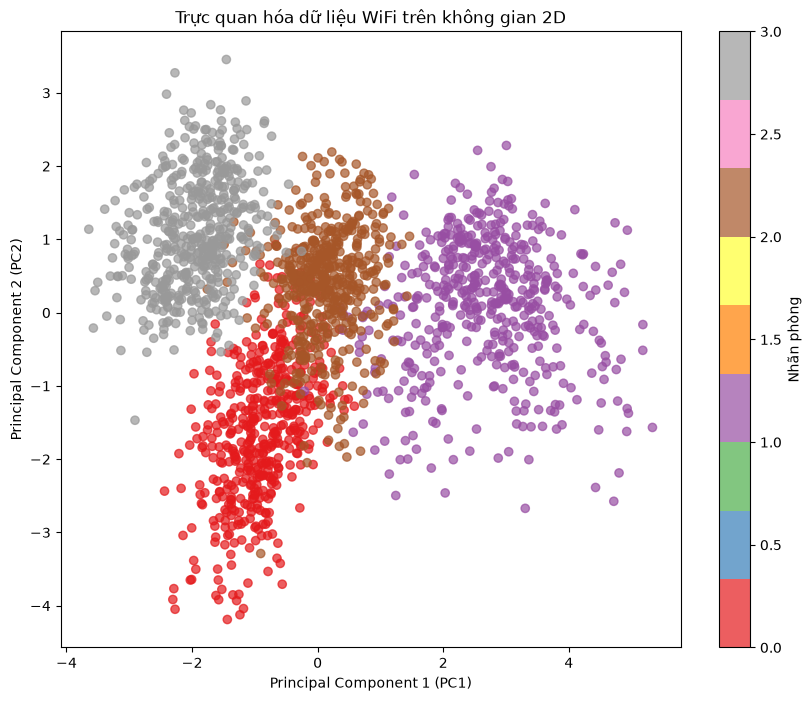

In [25]:
print("YÊU CẦU 2: TRỰC QUAN HÓA BẰNG PCA")
X = df[numeric_cols]
y = df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='Set1', alpha=0.7)
plt.title("Trực quan hóa dữ liệu WiFi trên không gian 2D")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.colorbar(scatter, label="Nhãn phòng")
plt.show()

In [18]:
print("YÊU CẦU 3: HUẤN LUYỆN VÀ SO SÁNH MÔ HÌNH (10-Fold CV)")
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
f1_macro = make_scorer(f1_score, average='macro')

models = {
    'KNN': {
        'estimator': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
    },
    'SVM': {
        'estimator': SVC(random_state=42),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
    }
}

ket_qua = []
for name, config in models.items():
    print(f"Đang tinh chỉnh và huấn luyện: {name}...")
    grid = GridSearchCV(config['estimator'], config['params'], cv=cv, scoring=f1_macro, n_jobs=-1)
    grid.fit(X_scaled, y_encoded)
    ket_qua.append({
        'Mô hình': name,
        'Tham số tối ưu': str(grid.best_params_),
        'F-Score (10-fold CV)': round(grid.best_score_, 4)
    })

df_ket_qua = pd.DataFrame(ket_qua)
display(df_ket_qua)

YÊU CẦU 3: HUẤN LUYỆN VÀ SO SÁNH MÔ HÌNH (10-Fold CV)
Đang tinh chỉnh và huấn luyện: KNN...
Đang tinh chỉnh và huấn luyện: Random Forest...
Đang tinh chỉnh và huấn luyện: SVM...


,Mô hình,Tham số tối ưu,F-Score (10-fold CV)
0,KNN,"{'n_neighbors': 3, 'weights': 'uniform'}",0.9875
1,Random Forest,"{'max_depth': None, 'n_estimators': 50}",0.9830
2,SVM,"{'C': 10, 'kernel': 'rbf'}",0.9835


In [21]:
print("YÊU CẦU 4: GOM CỤM K-MEANS & DBSCAN")
so_cum = len(np.unique(y_encoded)) 

kmeans = KMeans(n_clusters=so_cum, random_state=42, n_init=10)
dbscan = DBSCAN(eps=0.5, min_samples=5)

nhan_kmeans = kmeans.fit_predict(X_scaled)
nhan_dbscan = dbscan.fit_predict(X_scaled)

diem_gom_cum = pd.DataFrame({
    'Thuật toán': ['K-Means', 'DBSCAN'],
    'Adjusted Rand Index (ARI)': [
        adjusted_rand_score(y_encoded, nhan_kmeans),
        adjusted_rand_score(y_encoded, nhan_dbscan)
    ],
    'Normalized Mutual Info (NMI)': [
        normalized_mutual_info_score(y_encoded, nhan_kmeans),
        normalized_mutual_info_score(y_encoded, nhan_dbscan)
    ]
})
display(diem_gom_cum)

YÊU CẦU 4: GOM CỤM K-MEANS & DBSCAN


,Thuật toán,Adjusted Rand Index (ARI),Normalized Mutual Info (NMI)
0,K-Means,0.818237,0.80423
1,DBSCAN,0.007477,0.15525
